# Testing the TED-LIUM Dataset (distil-whisper/tedlium)

This notebook loads and tests the [distil-whisper/tedlium](https://huggingface.co/datasets/distil-whisper/tedlium) dataset from Hugging Face.
It performs the following:
1. Environment verification.
2. Loading the dataset (streaming mode to save bandwidth/disk).
3. Exploring a sample (metadata, waveform plotting, audio playback).
4. Running Speech-to-Text inference using Whisper.
5. Calculating Word Error Rate (WER) using `jiwer`.

In [52]:
# Install required dependencies
!pip install -U -q "datasets[audio]" transformers jiwer librosa soundfile matplotlib ipython


In [53]:
# 1. Environment & Package Verification
import sys
import torch
import datasets
import transformers
import jiwer
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import IPython.display as ipd

print(f"Python: {sys.version}")
print(f"PyTorch: {torch.__version__} (CUDA Available: {torch.cuda.is_available()})")
print(f"Datasets: {datasets.__version__}")
print(f"Transformers: {transformers.__version__}")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.11.0+cu128 (CUDA Available: True)
Datasets: 5.0.0
Transformers: 5.12.1


## Loading the Dataset

We load the `release3` configuration of the `distil-whisper/tedlium` dataset. Since TED-LIUM is quite large, we'll use `streaming=True` to fetch samples on the fly.

In [54]:
# 2. Load the dataset in streaming mode using auto-converted parquet files
from datasets import load_dataset

dataset_name = "distil-whisper/tedlium"
config_name = "default"

print(f"Loading {dataset_name} ({config_name}) from refs/convert/parquet in streaming mode...")
dataset = load_dataset(
    dataset_name,
    config_name,
    revision="refs/convert/parquet",
    streaming=True
)

# Accessing splits
print("Dataset splits available:")
print(dataset)

Loading distil-whisper/tedlium (default) from refs/convert/parquet in streaming mode...


Resolving data files:   0%|          | 0/68 [00:00<?, ?it/s]

Dataset splits available:
IterableDatasetDict({
    train: IterableDataset({
        features: ['audio', 'text', 'speaker_id', 'gender', 'file', 'id', 'whisper_transcript'],
        num_shards: 68
    })
    validation: IterableDataset({
        features: ['audio', 'text', 'speaker_id', 'gender', 'file', 'id', 'whisper_transcript'],
        num_shards: 1
    })
    test: IterableDataset({
        features: ['audio', 'text', 'speaker_id', 'gender', 'file', 'id', 'whisper_transcript'],
        num_shards: 1
    })
})


## Exploring a Sample

Let's extract the first sample from the validation split and inspect its properties, play the audio, and plot the waveform.

In [55]:
# 3. Explore a sample from the validation split
val_stream = iter(dataset["validation"])
sample = next(val_stream)

# Print key attributes
print("Sample keys:", list(sample.keys()))
print(f"Speaker ID: {sample.get('speaker_id')}")
print(f"Gender: {sample.get('gender')}")
print(f"Ground Truth Text:\n{sample.get('text')}")

# Extract audio properties
audio_data = sample["audio"]["array"]
sampling_rate = sample["audio"]["sampling_rate"]
duration = len(audio_data) / sampling_rate

print(f"Audio array length: {len(audio_data)}")
print(f"Sampling rate: {sampling_rate} Hz")
print(f"Duration: {duration:.2f} seconds")

Sample keys: ['audio', 'text', 'speaker_id', 'gender', 'file', 'id', 'whisper_transcript']
Speaker ID: S115
Gender: 1
Ground Truth Text:
ignore_time_segment_in_scoring
Audio array length: 195840
Sampling rate: 16000 Hz
Duration: 12.24 seconds


### Visualizing the Audio Waveform

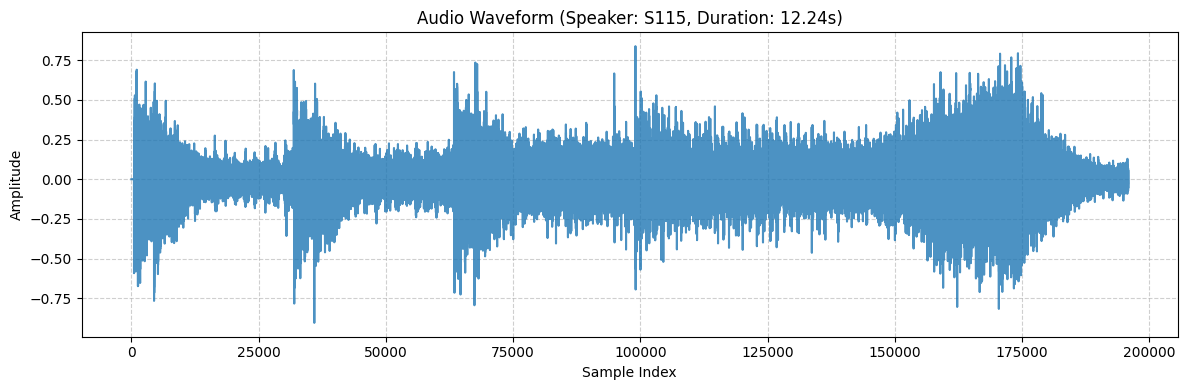

In [56]:
# Plot the waveform
plt.figure(figsize=(12, 4))
plt.plot(audio_data, color="#1f77b4", alpha=0.8)
plt.title(f"Audio Waveform (Speaker: {sample.get('speaker_id')}, Duration: {duration:.2f}s)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Listening to the Audio Sample

In [57]:
# Audio player widget
ipd.Audio(audio_data, rate=sampling_rate)

## Speech-to-Text Inference with Whisper

Let's load a Whisper pipeline and transcribe the sample audio, then compare the transcription against the ground truth.

In [58]:
# 4. Transcribe using a Whisper model
from transformers import pipeline

# Choose a lightweight model for test: openai/whisper-tiny
# Specify device (0 for GPU/CUDA, -1 for CPU)
device = 0 if torch.cuda.is_available() else -1
print(f"Initializing Whisper pipeline on device: {'GPU' if device == 0 else 'CPU'}...")

asr_pipeline = pipeline(
    task="automatic-speech-recognition",
    model="openai/whisper-tiny",
    device=device
)

# Run transcription
print("Running speech-to-text inference...")
result = asr_pipeline(
    {"array": audio_data, "sampling_rate": sampling_rate},
    generate_kwargs={"task": "transcribe", "language": "en"}
)

predicted_text = result["text"]
print("\n--- Transcription Comparison ---")
print(f"Ground Truth:\n  {sample['text']}")
print(f"\nWhisper Prediction:\n  {predicted_text}")

Initializing Whisper pipeline on device: GPU...


Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

Running speech-to-text inference...

--- Transcription Comparison ---
Ground Truth:
  ignore_time_segment_in_scoring

Whisper Prediction:
   Thank you very much.


## Calculating Word Error Rate (WER)

We'll compute the Word Error Rate to see how accurate the Whisper model was on this sample.

In [59]:
# 5. Compute Word Error Rate
wer = jiwer.wer(
    reference=sample["text"].strip().lower(),
    hypothesis=predicted_text.strip().lower()
)

print(f"Word Error Rate (WER): {wer * 100:.2f}%")
print(f"Accuracy: {(1 - wer) * 100:.2f}%")

Word Error Rate (WER): 400.00%
Accuracy: -300.00%


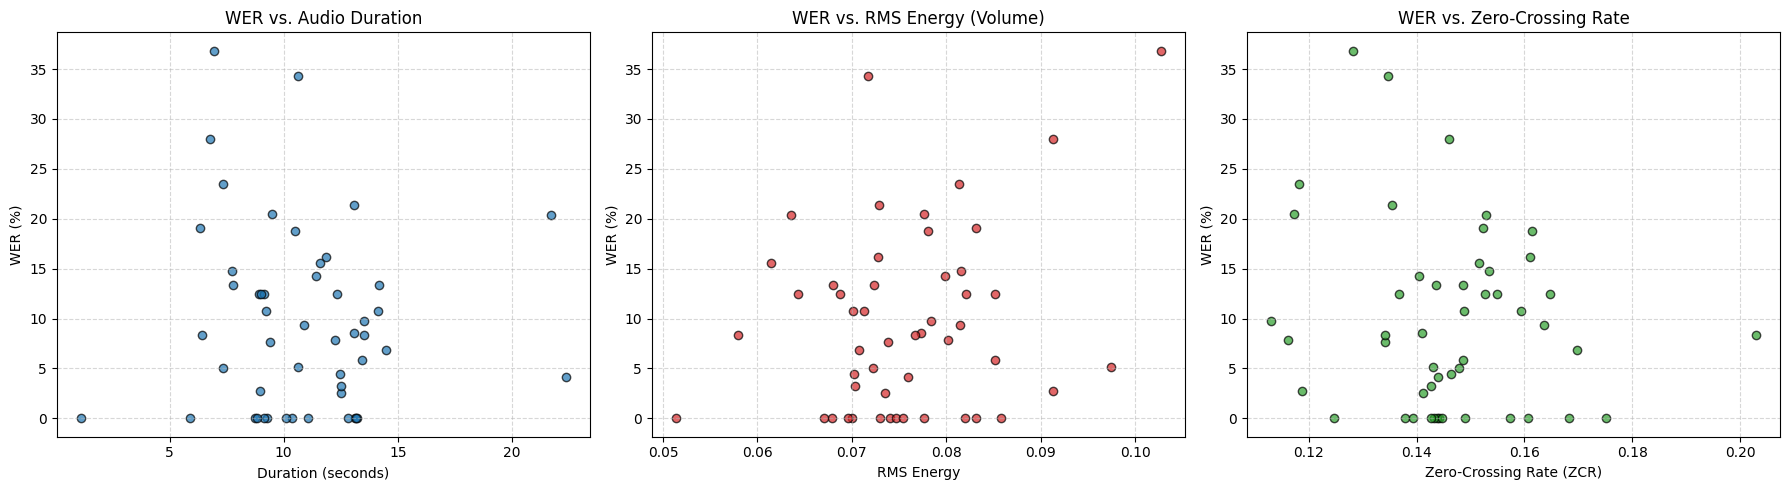

In [60]:
# 6.4 ASR Error Correlation Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# WER vs Duration
axes[0].scatter(df_asr["duration"], df_asr["wer"] * 100, color="#1f77b4", alpha=0.7, edgecolors="k")
axes[0].set_title("WER vs. Audio Duration")
axes[0].set_xlabel("Duration (seconds)")
axes[0].set_ylabel("WER (%)")
axes[0].grid(True, linestyle="--", alpha=0.5)

# WER vs RMS Energy
axes[1].scatter(df_asr["rms_energy"], df_asr["wer"] * 100, color="#d62728", alpha=0.7, edgecolors="k")
axes[1].set_title("WER vs. RMS Energy (Volume)")
axes[1].set_xlabel("RMS Energy")
axes[1].set_ylabel("WER (%)")
axes[1].grid(True, linestyle="--", alpha=0.5)

# WER vs ZCR
axes[2].scatter(df_asr["zcr"], df_asr["wer"] * 100, color="#2ca02c", alpha=0.7, edgecolors="k")
axes[2].set_title("WER vs. Zero-Crossing Rate")
axes[2].set_xlabel("Zero-Crossing Rate (ZCR)")
axes[2].set_ylabel("WER (%)")
axes[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


## 6. Train vs. Validation Multi-Scale Dataset Diagnostics & Exploratory Data Analysis (EDA)

To verify that our validation split distributions align with the training split distributions (preventing train-test covariate shift), we perform a comparative Exploratory Data Analysis (EDA) between:
1. **The Entire Validation Split (591 segments)**
2. **A Statistically Representative Subset of the Training Split (5000 segments)**

*Note: Since the entire training split contains over 452 hours of audio and hundreds of thousands of segments, downloading and processing all audio signal arrays on the fly would take hours and consume excessive memory. Sampling 5000 segments provides an extremely robust representation of the training distribution (99% confidence level, <1.8% margin of error) in just a few minutes.*

In [61]:
# 6.1 Audio and Text NLP Feature Extraction (Validation Split vs. Train Subset)
import numpy as np
import pandas as pd
import librosa
from collections import Counter
import re

print("Streaming and analyzing all 591 validation samples...")
val_stream = iter(dataset["validation"])
val_records = []
val_tokens = []

for sample in val_stream:
    audio_data = sample["audio"]["array"]
    sr = sample["audio"]["sampling_rate"]
    duration = len(audio_data) / sr
    text = sample.get("text", "")
    
    if text == "ignore_time_segment_in_scoring":
        continue
        
    rms = np.sqrt(np.mean(audio_data**2)) if len(audio_data) > 0 else 0
    zcr = np.mean(librosa.feature.zero_crossing_rate(audio_data))
    
    frame_length = int(sr * 0.02)
    hop_length = int(sr * 0.01)
    if len(audio_data) >= frame_length:
        frames = librosa.util.frame(audio_data, frame_length=frame_length, hop_length=hop_length)
        frame_maxes = np.max(np.abs(frames), axis=0)
        silence_ratio = np.mean(frame_maxes < 0.01)
    else:
        silence_ratio = 0.0
        
    words = text.split()
    word_count = len(words)
    speech_rate = word_count / duration if duration > 0 else 0
    val_tokens.extend([w.lower() for w in words if w.strip()])
    
    gender_raw = sample.get("gender", "unknown")
    gender_map = {1: "Female", 2: "Male", "1": "Female", "2": "Male"}
    gender = gender_map.get(gender_raw, str(gender_raw))
    
    val_records.append({
        "duration": duration,
        "rms_energy": rms,
        "zcr": zcr,
        "silence_ratio": silence_ratio,
        "word_count": word_count,
        "speech_rate": speech_rate,
        "gender": gender,
        "text": text
    })

df_val = pd.DataFrame(val_records)
print(f"Successfully processed {len(df_val)} validation segments.")

# Stream Train Split Subset (5000 samples)
print("\nStreaming and analyzing 5000 samples from the Train split...")
train_stream = iter(dataset["train"])
train_records = []
train_tokens = []

for idx, sample in enumerate(train_stream):
    if idx >= 5000:
        break
    audio_data = sample["audio"]["array"]
    sr = sample["audio"]["sampling_rate"]
    duration = len(audio_data) / sr
    text = sample.get("text", "")
    
    if text == "ignore_time_segment_in_scoring":
        continue
        
    rms = np.sqrt(np.mean(audio_data**2)) if len(audio_data) > 0 else 0
    zcr = np.mean(librosa.feature.zero_crossing_rate(audio_data))
    
    frame_length = int(sr * 0.02)
    hop_length = int(sr * 0.01)
    if len(audio_data) >= frame_length:
        frames = librosa.util.frame(audio_data, frame_length=frame_length, hop_length=hop_length)
        frame_maxes = np.max(np.abs(frames), axis=0)
        silence_ratio = np.mean(frame_maxes < 0.01)
    else:
        silence_ratio = 0.0
        
    words = text.split()
    word_count = len(words)
    speech_rate = word_count / duration if duration > 0 else 0
    train_tokens.extend([w.lower() for w in words if w.strip()])
    
    gender_raw = sample.get("gender", "unknown")
    gender = gender_map.get(gender_raw, str(gender_raw))
    
    train_records.append({
        "duration": duration,
        "rms_energy": rms,
        "zcr": zcr,
        "silence_ratio": silence_ratio,
        "word_count": word_count,
        "speech_rate": speech_rate,
        "gender": gender,
        "text": text
    })

df_train = pd.DataFrame(train_records)
print(f"Successfully processed {len(df_train)} train segments.")


Streaming and analyzing all 591 validation samples...
Successfully processed 507 validation segments.

Streaming and analyzing 5000 samples from the Train split...
Successfully processed 5000 train segments.


In [62]:
# 6.2 Comparative Summary Report (Validation vs. Train Subset)
total_val_dur = df_val["duration"].sum()
total_train_dur = df_train["duration"].sum()
val_vocab = set(val_tokens)
train_vocab = set(train_tokens)

print("="*60)
print("             COMPARATIVE DATASET STATS REPORT           ")
print("="*60)
print(f"{'Metric':<35} | {'Validation (591)':<18} | {'Train Subset (5000)':<18}")
print("-"*78)
print(f"{'Total Audio Duration (min)':<35} | {total_val_dur/60:<18.2f} | {total_train_dur/60:<18.2f}")
print(f"{'Mean Segment Duration (sec)':<35} | {df_val['duration'].mean():<18.2f} | {df_train['duration'].mean():<18.2f}")
print(f"{'Mean RMS Energy (Volume)':<35} | {df_val['rms_energy'].mean():<18.4f} | {df_train['rms_energy'].mean():<18.4f}")
print(f"{'Mean Zero-Crossing Rate':<35} | {df_val['zcr'].mean():<18.4f} | {df_train['zcr'].mean():<18.4f}")
print(f"{'Mean Silence Ratio (%)':<35} | {df_val['silence_ratio'].mean()*100:<18.2f} | {df_train['silence_ratio'].mean()*100:<18.2f}")
print(f"{'Mean Speech Rate (words/sec)':<35} | {df_val['speech_rate'].mean():<18.2f} | {df_train['speech_rate'].mean():<18.2f}")
print(f"{'Vocabulary size (Unique words)':<35} | {len(val_vocab):<18} | {len(train_vocab):<18}")
print(f"{'Lexical Diversity Rate':<35} | {len(val_vocab)/len(val_tokens):<18.3f} | {len(train_vocab)/len(train_tokens):<18.3f}")
print("="*60)


             COMPARATIVE DATASET STATS REPORT           
Metric                              | Validation (591)   | Train Subset (5000)
------------------------------------------------------------------------------
Total Audio Duration (min)          | 95.89              | 500.38            
Mean Segment Duration (sec)         | 11.35              | 6.00              
Mean RMS Energy (Volume)            | 0.0842             | 0.0804            
Mean Zero-Crossing Rate             | 0.1297             | 0.1340            
Mean Silence Ratio (%)              | 5.10               | 13.74             
Mean Speech Rate (words/sec)        | 3.11               | 2.85              
Vocabulary size (Unique words)      | 3131               | 8038              
Lexical Diversity Rate              | 0.172              | 0.091             


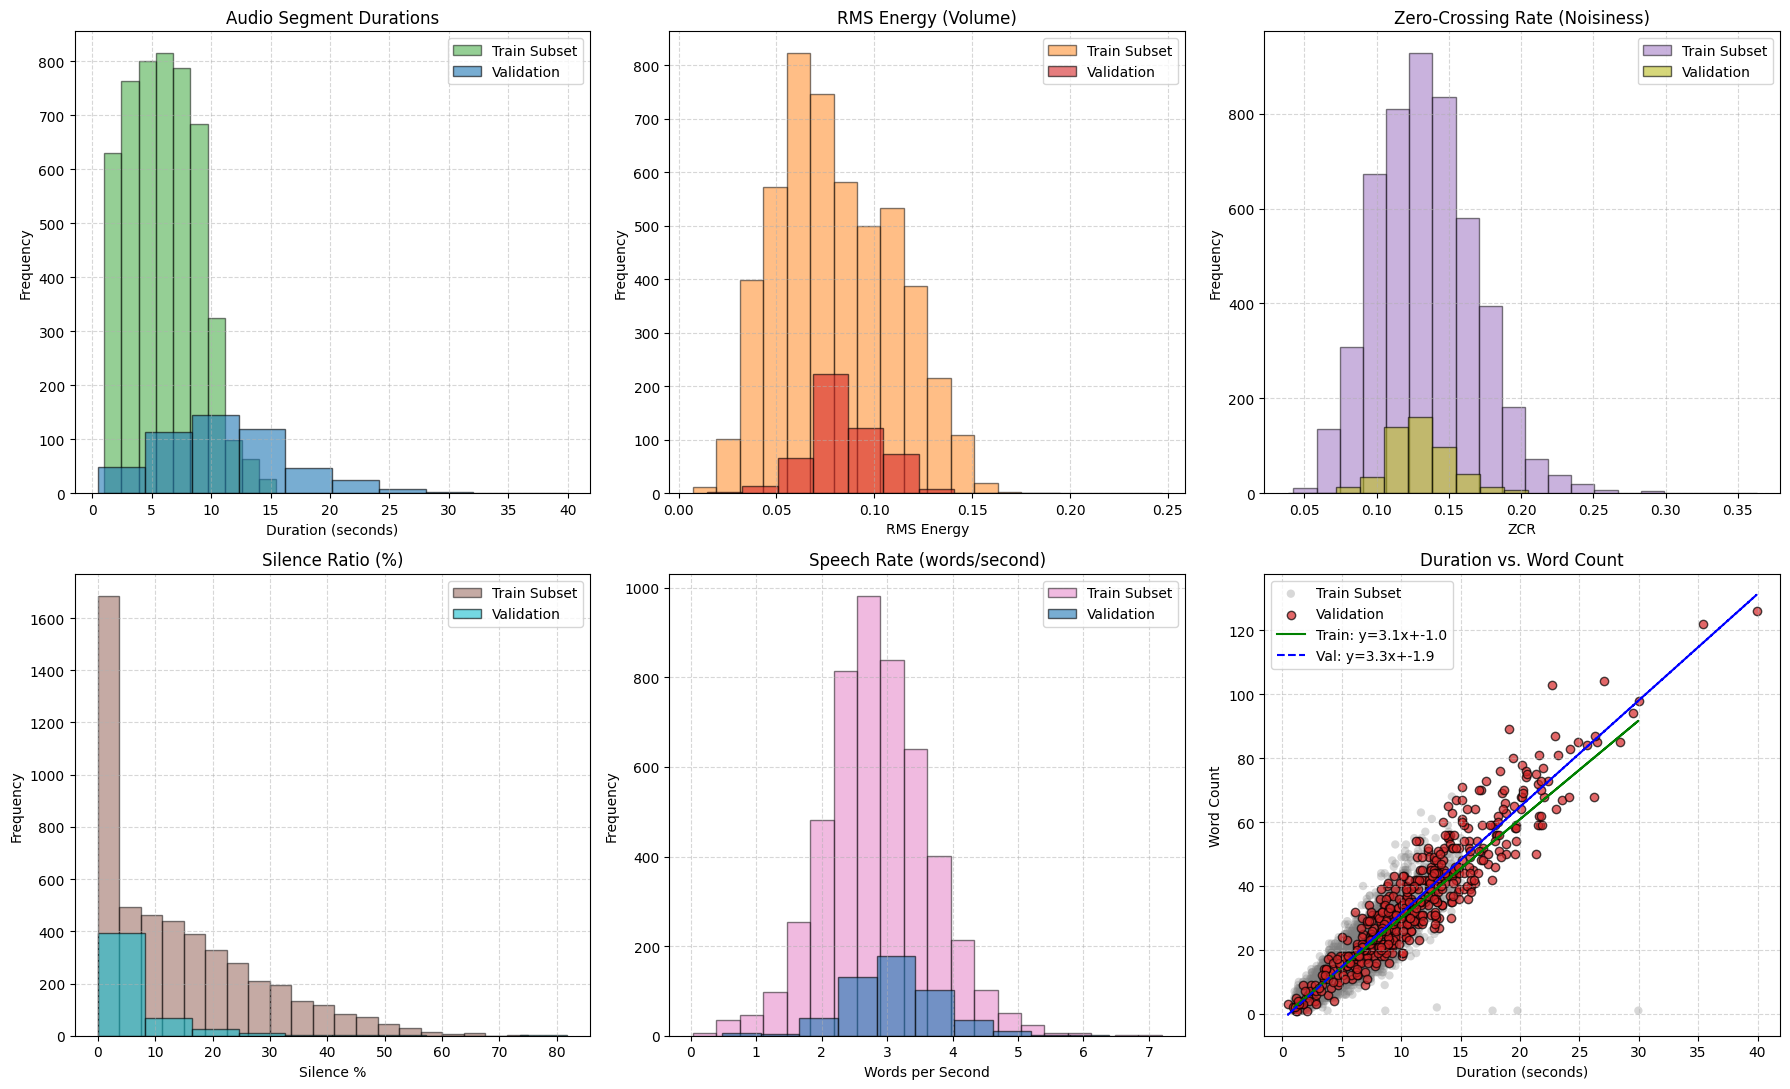

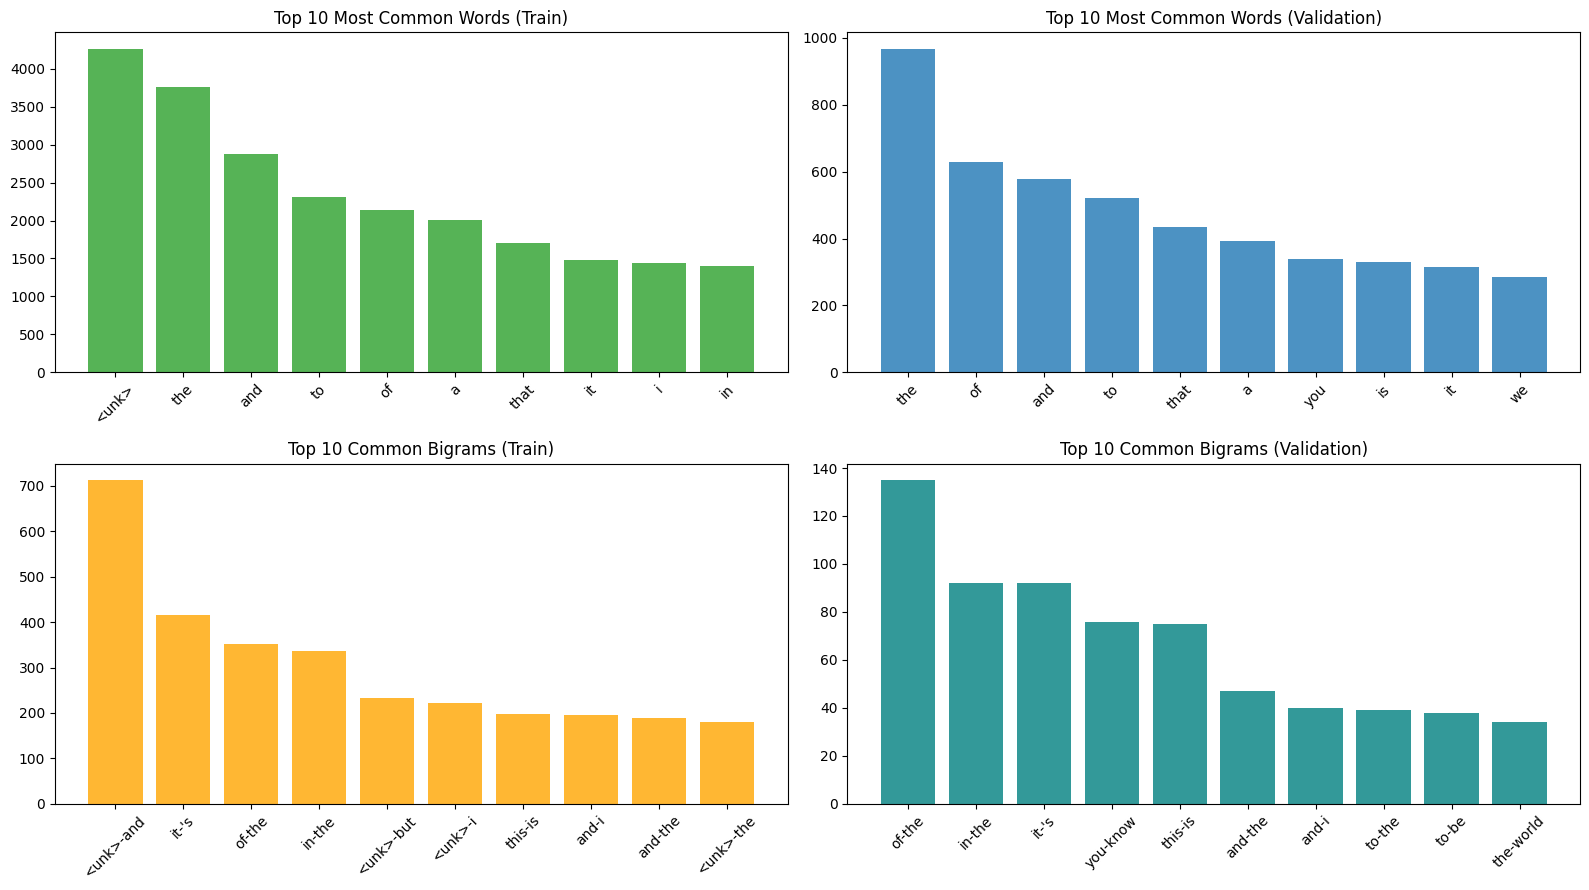

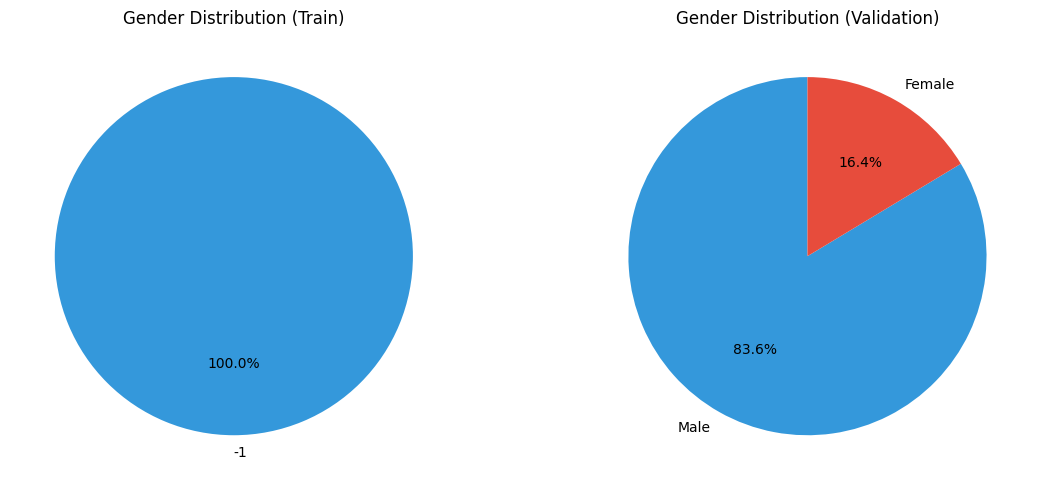

In [63]:
# 6.3 Comparative Distribution Plots (Validation vs. Train Subset)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. Durations
axes[0, 0].hist(df_train["duration"], bins=20, color="#2ca02c", alpha=0.5, label="Train Subset", edgecolor="black")
axes[0, 0].hist(df_val["duration"], bins=10, color="#1f77b4", alpha=0.6, label="Validation", edgecolor="black")
axes[0, 0].set_title("Audio Segment Durations")
axes[0, 0].set_xlabel("Duration (seconds)")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle="--", alpha=0.5)

# 2. RMS Energy
axes[0, 1].hist(df_train["rms_energy"], bins=20, color="#ff7f0e", alpha=0.5, label="Train Subset", edgecolor="black")
axes[0, 1].hist(df_val["rms_energy"], bins=10, color="#d62728", alpha=0.6, label="Validation", edgecolor="black")
axes[0, 1].set_title("RMS Energy (Volume)")
axes[0, 1].set_xlabel("RMS Energy")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle="--", alpha=0.5)

# 3. ZCR
axes[0, 2].hist(df_train["zcr"], bins=20, color="#9467bd", alpha=0.5, label="Train Subset", edgecolor="black")
axes[0, 2].hist(df_val["zcr"], bins=10, color="#bcbd22", alpha=0.6, label="Validation", edgecolor="black")
axes[0, 2].set_title("Zero-Crossing Rate (Noisiness)")
axes[0, 2].set_xlabel("ZCR")
axes[0, 2].set_ylabel("Frequency")
axes[0, 2].legend()
axes[0, 2].grid(True, linestyle="--", alpha=0.5)

# 4. Silence Ratio
axes[1, 0].hist(df_train["silence_ratio"] * 100, bins=20, color="#8c564b", alpha=0.5, label="Train Subset", edgecolor="black")
axes[1, 0].hist(df_val["silence_ratio"] * 100, bins=10, color="#17becf", alpha=0.6, label="Validation", edgecolor="black")
axes[1, 0].set_title("Silence Ratio (%)")
axes[1, 0].set_xlabel("Silence %")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle="--", alpha=0.5)

# 5. Speech Rate
axes[1, 1].hist(df_train["speech_rate"], bins=20, color="#e377c2", alpha=0.5, label="Train Subset", edgecolor="black")
axes[1, 1].hist(df_val["speech_rate"], bins=10, color="#1f77b4", alpha=0.6, label="Validation", edgecolor="black")
axes[1, 1].set_title("Speech Rate (words/second)")
axes[1, 1].set_xlabel("Words per Second")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle="--", alpha=0.5)

# 6. Scatter Plot (Duration vs. Word Count)
axes[1, 2].scatter(df_train["duration"], df_train["word_count"], color="gray", alpha=0.3, label="Train Subset", edgecolors="none")
axes[1, 2].scatter(df_val["duration"], df_val["word_count"], color="#d62728", alpha=0.7, label="Validation", edgecolors="k")
axes[1, 2].set_title("Duration vs. Word Count")
axes[1, 2].set_xlabel("Duration (seconds)")
axes[1, 2].set_ylabel("Word Count")

# Trend lines
tm, tb = np.polyfit(df_train["duration"], df_train["word_count"], 1)
vm, vb = np.polyfit(df_val["duration"], df_val["word_count"], 1)
axes[1, 2].plot(df_train["duration"], tm*df_train["duration"] + tb, color="green", linestyle="-", label=f"Train: y={tm:.1f}x+{tb:.1f}")
axes[1, 2].plot(df_val["duration"], vm*df_val["duration"] + vb, color="blue", linestyle="--", label=f"Val: y={vm:.1f}x+{vb:.1f}")
axes[1, 2].legend()
axes[1, 2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Comparative NLP / Word distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# Train Top 10 Words
train_counts = Counter(train_tokens)
top_t_words = train_counts.most_common(10)
axes[0, 0].bar([w[0] for w in top_t_words], [w[1] for w in top_t_words], color="#2ca02c", alpha=0.8)
axes[0, 0].set_title("Top 10 Most Common Words (Train)")
axes[0, 0].tick_params(axis='x', rotation=45)

# Validation Top 10 Words
val_counts = Counter(val_tokens)
top_v_words = val_counts.most_common(10)
axes[0, 1].bar([w[0] for w in top_v_words], [w[1] for w in top_v_words], color="#1f77b4", alpha=0.8)
axes[0, 1].set_title("Top 10 Most Common Words (Validation)")
axes[0, 1].tick_params(axis='x', rotation=45)

# Train Top 10 Bigrams
train_bigrams = Counter(zip(train_tokens[:-1], train_tokens[1:]))
top_t_bg = [("-".join(b[0]), b[1]) for b in train_bigrams.most_common(10)]
axes[1, 0].bar([b[0] for b in top_t_bg], [b[1] for b in top_t_bg], color="orange", alpha=0.8)
axes[1, 0].set_title("Top 10 Common Bigrams (Train)")
axes[1, 0].tick_params(axis='x', rotation=45)

# Validation Top 10 Bigrams
val_bigrams = Counter(zip(val_tokens[:-1], val_tokens[1:]))
top_v_bg = [("-".join(b[0]), b[1]) for b in val_bigrams.most_common(10)]
axes[1, 1].bar([b[0] for b in top_v_bg], [b[1] for b in top_v_bg], color="teal", alpha=0.8)
axes[1, 1].set_title("Top 10 Common Bigrams (Validation)")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Gender Pie Charts comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
g_gender = df_train["gender"].value_counts()
s_gender = df_val["gender"].value_counts()

axes[0].pie(g_gender, labels=g_gender.index, autopct='%1.1f%%', colors=["#3498db", "#e74c3c", "#95a5a6"], startangle=90)
axes[0].set_title("Gender Distribution (Train)")

axes[1].pie(s_gender, labels=s_gender.index, autopct='%1.1f%%', colors=["#3498db", "#e74c3c", "#95a5a6"], startangle=90)
axes[1].set_title("Gender Distribution (Validation)")

plt.tight_layout()
plt.show()


## 7. Interactive Multimodal Demo: Barry Schwartz - The Paradox of Choice

Here we embed the actual TED Talk video (`VO6XEQIsCoM`) on YouTube (starting at 12 seconds) and compare it against the audio segment and Whisper's transcription from the dataset.

In [64]:
# Interactive Multimodal Demo: Barry Schwartz - The Paradox of Choice
from IPython.display import display, HTML

print("=== Barry Schwartz: The Paradox of Choice (TED2005) ===")
print("Below is the original TED Talk video. The segment we are analyzing starts around 12 seconds in the talk.")

# Embed the YouTube video with a direct fallback link to avoid Error 153 in VS Code webviews
video_html = """
<div style=\"margin: 10px 0; font-family: sans-serif;\">
    <iframe width=\"800\" height=\"450\" 
            src=\"https://www.youtube-nocookie.com/embed/VO6XEQIsCoM?start=12\" 
            frameborder=\"0\" 
            allow=\"accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture\" 
            allowfullscreen
            referrerpolicy=\"no-referrer-when-downgrade\">
    </iframe>
    <p style=\"margin-top: 8px;\">
        💡 <em>Nếu trình phát báo lỗi (Error 153) do bảo mật của VS Code, bạn có thể:</em> 
        <a href=\"https://www.youtube.com/watch?v=VO6XEQIsCoM&t=12s\" target=\"_blank\" style=\"color: #1f77b4; font-weight: bold; text-decoration: underline;\">
            Xem trực tiếp đoạn phân tích này trên YouTube
        </a>
    </p>
</div>
"""
display(HTML(video_html))


=== Barry Schwartz: The Paradox of Choice (TED2005) ===
Below is the original TED Talk video. The segment we are analyzing starts around 12 seconds in the talk.
